In [2]:
import meep as mp
import meep.adjoint as mpa
import autograd.numpy as npa
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.image as mpimg
import matplotlib.patches as patches
from autograd import tensor_jacobian_product
import numpy as np
import nlopt
import os
import glob
from tqdm.auto import tqdm

After import we setup the variables that define constants of simulation and constant geometry for optimization
### Simulation Constants 

In [3]:
# ----- Parameters (edit these to explore) -----
WAVEGUIDE_WIDTH = 0.5       # width of input/output waveguides (µm)
DESIGN_REGION_WIDTH = 2.5   # width of the MMI design region
DESIGN_REGION_HEIGHT = 2.5  # height of the MMI design region
ARM_SEPARATION = 1.0        # vertical separation between the two output arms
WAVEGUIDE_LENGTH = 0.5      # length of straight waveguide before/after design region
PML_SIZE = 1.0
RESOLUTION = 20             # pixels/µm 

# Materials (common Si / SiO2 for 1.55 µm)
Si = mp.Medium(index=3.4)
SiO2 = mp.Medium(index=1.44)


#### Geometry and Preview

In [4]:
# ----- Simulation cell -----
# Total cell: PML + waveguide + design region + waveguide + PML in x;
#             PML + design_region_height + margin in y.
Sx = 2 * PML_SIZE + 2 * WAVEGUIDE_LENGTH + DESIGN_REGION_WIDTH
Sy = 2 * PML_SIZE + DESIGN_REGION_HEIGHT + 0.5
cell_size = mp.Vector3(Sx, Sy)
pml_layers = [mp.PML(PML_SIZE)]


# ----- Design region (the box we will optimize) -----
# Resolution in the design region is often finer than the simulation.
design_region_resolution = int(5 * RESOLUTION)
Nx = int(design_region_resolution * DESIGN_REGION_WIDTH) + 1
Ny = int(design_region_resolution * DESIGN_REGION_HEIGHT) + 1

# MaterialGrid: interpolates between SiO2 (weight 0) and Si (weight 1).
# Initial weights = 0.5 (gray); we'll optimize them later.
design_variables = mp.MaterialGrid(
    mp.Vector3(Nx, Ny),
    SiO2,
    Si,
    grid_type="U_MEAN",
)
design_region = mpa.DesignRegion(
    design_variables,
    volume=mp.Volume(
        center=mp.Vector3(),
        size=mp.Vector3(DESIGN_REGION_WIDTH, DESIGN_REGION_HEIGHT, 0),
    ),
)

# ----- Geometry: input waveguide, two output arms, design region -----
# Left: one input waveguide. Right: two output waveguides (top and bottom).
geometry = [
    # Left waveguide (input)
    mp.Block(
        center=mp.Vector3(x=-Sx / 4),
        material=Si,
        size=mp.Vector3(Sx / 2 + 1, WAVEGUIDE_WIDTH, 0),
    ),
    # Top right output arm
    mp.Block(
        center=mp.Vector3(x=Sx / 4, y=ARM_SEPARATION / 2),
        material=Si,
        size=mp.Vector3(Sx / 2 + 1, WAVEGUIDE_WIDTH, 0),
    ),
    # Bottom right output arm
    mp.Block(
        center=mp.Vector3(x=Sx / 4, y=-ARM_SEPARATION / 2),
        material=Si,
        size=mp.Vector3(Sx / 2 + 1, WAVEGUIDE_WIDTH, 0),
    ),
    # Design region (optimizable)
    mp.Block(
        center=design_region.center,
        size=design_region.size,
        material=design_variables,
    ),
]


#### Preview


block, center = (-1.375,0,0)
          size (3.75,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     block, center = (1.375,0.5,0)
          size (3.75,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     block, center = (1.375,-0.5,0)
          size (3.75,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     block, center = (0,0,0)
          size (2.5,2.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)


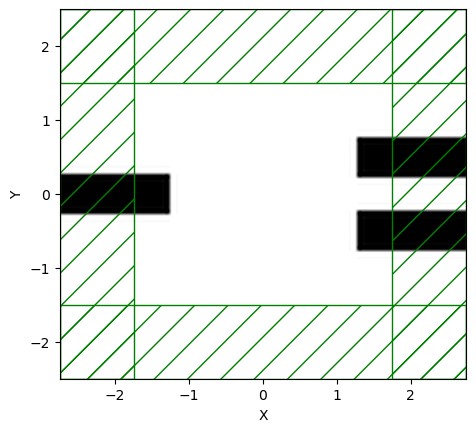

Cell: 5.5 x 5.0 µm. Design grid: 251 x 251


In [5]:
simp = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    default_material=SiO2,
    resolution=RESOLUTION,
)

simp.plot2D()
# plt.savefig("geometry.png")
plt.show()
print("Cell:", Sx, "x", Sy, "µm. Design grid:", Nx, "x", Ny)



#### Prepare main sim, source and monitors

In [6]:
fcen = 1 / 1.56
fwidth = 0.2 * fcen
source_center = mp.Vector3(-Sx / 2 + PML_SIZE + WAVEGUIDE_LENGTH / 3, 0, 0)
source_size = mp.Vector3(0, 2, 0)
kpoint = mp.Vector3(1, 0, 0)
source = [
    mp.EigenModeSource(
        mp.GaussianSource(frequency=fcen, fwidth=fwidth),
        eig_band=1, direction=mp.NO_DIRECTION, eig_kpoint=kpoint,
        size=source_size, center=source_center,
    )
]

# Multiple frequencies for broadband design
frequencies = 1 / np.linspace(1.5, 1.6, 5)


sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=SiO2,
    resolution=RESOLUTION,
)


#Setting output directory of Sim
sim.use_output_directory("outputs")

'outputs'

In [7]:
mode = 1

#setting the geometry volume region for the mode monitors

TE0_vol = mp.Volume( center=mp.Vector3(x=-Sx / 2 + PML_SIZE + 2 * WAVEGUIDE_LENGTH / 3), size=mp.Vector3(y=1.5),)
TEtop_vol = mp.Volume( center=mp.Vector3(Sx / 2 - PML_SIZE - 2 * WAVEGUIDE_LENGTH / 3, ARM_SEPARATION / 2, 0), size=mp.Vector3(y=ARM_SEPARATION),)
TEbot_vol = mp.Volume( center=mp.Vector3(Sx / 2 - PML_SIZE - 2 * WAVEGUIDE_LENGTH / 3, -ARM_SEPARATION / 2, 0), size=mp.Vector3(y=ARM_SEPARATION),)

vol_list=[TE0_vol, TEtop_vol, TEbot_vol]
TE0 = mpa.EigenmodeCoefficient(
    sim,
    TE0_vol,
    mode,
)
TE_top = mpa.EigenmodeCoefficient(
    sim,
    TEtop_vol,
    mode,
)
TE_bottom = mpa.EigenmodeCoefficient(
    sim,
    TEbot_vol,
    mode,
)
ob_list = [TE0, TE_top, TE_bottom]

#Objective function to rate the simulation.
def J(source, top, bottom):
    power = npa.abs(top / source) ** 2 + npa.abs(bottom / source) ** 2 
    return npa.mean(power)


opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=J,
    objective_arguments=ob_list,
    design_regions=[design_region],
    frequencies=frequencies,
    decay_by=1e-5,
)



In [8]:
## functions to allow me to draw volumes in matplotlib, simulation visualization beforehand.
def volume_bounds_xy(vol: mp.Volume):
    """Return (xmin, xmax, ymin, ymax) for a Volume in the XY plane."""
    c = vol.center
    s = vol.size

    # If any size component is 0 or None, treat it as 0 thickness in that axis.
    sx = s.x if s.x is not None else 0.0
    sy = s.y if s.y is not None else 0.0

    xmin = c.x - sx/2
    xmax = c.x + sx/2
    ymin = c.y - sy/2
    ymax = c.y + sy/2
    return xmin, xmax, ymin, ymax

def draw_volume(ax, vol: mp.Volume, *, color="cyan", lw=2, label=None):
    xmin, xmax, ymin, ymax = volume_bounds_xy(vol)
    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        label=label
    )
    ax.add_patch(rect)
    
def plot_geometry_with_volumes(sim: mp.Simulation, volumes, *,
                               plane=cell_size, center=mp.Vector3(), size=None,
                               eps_cmap="gray", title="Geometry + Volumes"):
    if size is None:
        size = sim.cell_size

    fig, ax = plt.subplots(figsize=(8, 4.5))

    # Plot epsilon (geometry) on this matplotlib axis
    sim.plot2D(ax=ax, output_plane=mp.Volume(center=center, size=size), fields=None)

    # Overlay volumes
    for (vol, color, label) in volumes:
        draw_volume(ax, vol, color=color, label=label)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # avoid duplicate legend entries
    handles, labels = ax.get_legend_handles_labels()
    if labels:
        uniq = dict(zip(labels, handles))
        ax.legend(uniq.values(), uniq.keys(), loc="upper right")

    plt.tight_layout()
    plt.show()

     block, center = (-1.375,0,0)
          size (3.75,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     block, center = (1.375,0.5,0)
          size (3.75,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     block, center = (1.375,-0.5,0)
          size (3.75,0.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (11.56,11.56,11.56)
     block, center = (0,0,0)
          size (2.5,2.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)


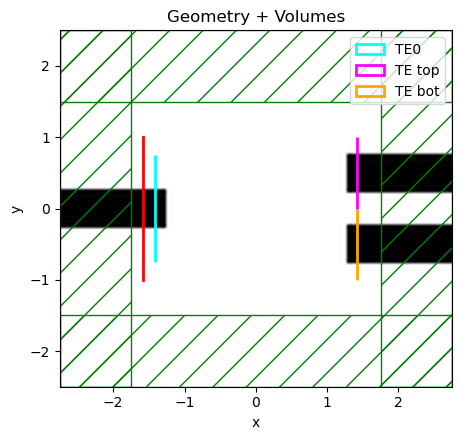

In [9]:
volumes_to_draw = [
    (TE0_vol,   "cyan",   "TE0"),
    (TEtop_vol, "magenta","TE top"),
    (TEbot_vol, "orange", "TE bot"),
]

plot_geometry_with_volumes(sim, volumes_to_draw)


In [10]:
# simulation output images for e-field with nothing
# sim.run(mp.at_every(0.6 , mp.output_png(mp.Ez, "-Zc dkbluered")), until=50)


In [11]:
# Convert previous images to a finished gif
# !magick -delay 10 -loop 0 ./outputs/*.png Efield.gif

In [12]:
#clear the image png files

# !rm ./outputs/*.h5

In [13]:
minimum_length = 0.09
eta_e = 0.55
filter_radius = mpa.get_conic_radius_from_eta_e(minimum_length, eta_e)
eta_i = 0.5

def mapping(x, eta, beta):
    """Filter -> tanh projection -> optional symmetry. Returns flattened weights."""
    filtered = mpa.conic_filter(
        x, filter_radius,
        DESIGN_REGION_WIDTH, DESIGN_REGION_HEIGHT,
        design_region_resolution,
    )
    projected = mpa.tanh_projection(filtered, beta, eta)
    # Enforce up-down symmetry (optional for symmetric splitter)
    projected = (npa.fliplr(projected) + projected) / 2
    return projected.flatten()



In [14]:
# ----- Boundary masks (waveguide ports stay Si, outer border SiO2) -----

x_g = np.linspace(-DESIGN_REGION_WIDTH / 2, DESIGN_REGION_WIDTH / 2, Nx)
y_g = np.linspace(-DESIGN_REGION_HEIGHT / 2, DESIGN_REGION_HEIGHT / 2, Ny)
X_g, Y_g = np.meshgrid(x_g, y_g, sparse=True, indexing="ij")

left_wg_mask = (X_g == -DESIGN_REGION_WIDTH / 2) & (np.abs(Y_g) <= WAVEGUIDE_WIDTH / 2)
top_right_wg_mask = (X_g == DESIGN_REGION_WIDTH / 2) & (
    np.abs(Y_g + ARM_SEPARATION / 2) <= WAVEGUIDE_WIDTH / 2
)
bottom_right_wg_mask = (X_g == DESIGN_REGION_WIDTH / 2) & (
    np.abs(Y_g - ARM_SEPARATION / 2) <= WAVEGUIDE_WIDTH / 2
)
Si_mask = left_wg_mask | top_right_wg_mask | bottom_right_wg_mask

border_mask = (
    (X_g == -DESIGN_REGION_WIDTH / 2) | (X_g == DESIGN_REGION_WIDTH / 2)
    | (Y_g == -DESIGN_REGION_HEIGHT / 2) | (Y_g == DESIGN_REGION_HEIGHT / 2)
)
SiO2_mask = border_mask.copy()
SiO2_mask[Si_mask] = False

In [ ]:
cur_iter = [0]
pbar_ref = [None]  # progress bar, set before loop so f() can update it

def f(v, gradient, cur_beta):
    x_mapped = mapping(v, eta_i, cur_beta)
    f0, dJ_du = opt([x_mapped])
    if gradient.size > 0:
        gradient[:] = tensor_jacobian_product(mapping, 0)(
            v, eta_i, cur_beta, np.sum(dJ_du, axis=1)
        )
    cur_iter[0] += 1
    if pbar_ref[0] is not None:
        pbar_ref[0].update(1)
        pbar_ref[0].set_postfix(obj=f"{np.real(f0):.6f}", refresh=False)
    return np.real(f0)

n = Nx * Ny
x = np.ones(n) * 0.5
x[Si_mask.flatten()] = 1.0
x[SiO2_mask.flatten()] = 0.0

lb = np.zeros(n)
lb[Si_mask.flatten()] = 1.0
ub = np.ones(n)
ub[SiO2_mask.flatten()] = 0.0

cur_beta = 4
beta_scale = 1.25
num_betas = 20
update_factor = 100

total_evals = num_betas * update_factor
pbar_ref[0] = tqdm(total=total_evals, desc="Optimization", unit=" eval")
verbo = mp.verbosity
verbo.mpb = 0
verbo.meep = 0
for _ in range(num_betas):
    solver = nlopt.opt(nlopt.LD_MMA, n)
    solver.set_lower_bounds(lb)
    solver.set_upper_bounds(ub)
    solver.set_max_objective(lambda a, g: f(a, g, cur_beta))
    solver.set_maxeval(update_factor)
    print(_)
    x[:] = solver.optimize(x)
    cur_beta = cur_beta * beta_scale
verbo.mpb = 1
verbo.meep = 1
pbar_ref[0].close()
pbar_ref[0] = None

print("Step 4 done: optimization loop completed.")
print("Final objective:", f(x, np.zeros(n), cur_beta))
mes = "This is an optimization for a 50:50 splitter along paths, a simple example"
index = 1
np.savez(
    "./opts/optimal_design%i.npz"%index,
    Message = mes,
    Geo = x,
    Objective = f(x, np.zeros(n), cur_beta),
    Beta = cur_beta,
    eta_i = eta_i,
    )

Optimization:   0%|          | 0/2000 [00:00<?, ? eval/s]

0
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gradient...
Starting forward run...
Starting adjoint run...
Calculating gr

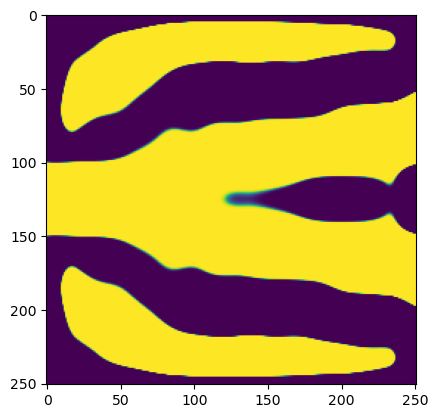

In [18]:
solution = np.load("./opts/optimal_design1.npz")
x = solution["Geo"]

cur_beta = int(solution.get("Beta", 4))
eta_i_loaded = float(solution.get("eta_i", eta_i))
finali = mapping(x, eta_i_loaded, 4**4)
score = solution.get("Objective", None)
plt.imshow(mapping(x, eta_i_loaded, cur_beta).reshape(Nx,Ny).T)

In [19]:
def plot_design_eps_overlay(ax, eps_flat, Nx, Ny, design_center, design_size,
                            *, alpha=0.65, cmap="binary", vmin=None, vmax=None):
    eps = np.array(eps_flat).reshape((Nx, Ny))  

    xmin = design_center.x - design_size.x/2
    xmax = design_center.x + design_size.x/2
    ymin = design_center.y - design_size.y/2
    ymax = design_center.y + design_size.y/2

    im = ax.imshow(
        eps.T,                      
        origin="lower",
        extent=(xmin, xmax, ymin, ymax),
        interpolation="nearest",
        alpha=alpha,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    return im


In [20]:
cur_beta

346

In [1]:
fig, ax = plt.subplots(figsize=(8, 4.5))

# overlay your three monitor volumes
draw_volume(ax, TE0_vol,   color="cyan",   label="TE0")
draw_volume(ax, TEtop_vol, color="magenta",label="TE top")
draw_volume(ax, TEbot_vol, color="orange", label="TE bot")

sim.plot2D(ax=ax, output_plane=mp.Volume(center=mp.Vector3(), size=sim.cell_size))
# overlay the design epsilon
im = plot_design_eps_overlay(ax, finali, Nx, Ny, mp.Vector3(), mp.Vector3(DESIGN_REGION_WIDTH, DESIGN_REGION_HEIGHT, 0))

plt.colorbar(im, ax=ax, label="epsilon (design region)")
ax.set_xlim([-Sx/2, Sx/2])
ax.set_ylim([-Sy/2, Sy/2])
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined